# Calibration of I0 (Initial Infected Humans)

This notebook visualizes the calibration of the initial number of infected humans (I0) and summarizes the selection outcome and ensemble behavior for the selected value.

Data source:
- Calibration outputs in `calib_I0_runs/` (one subfolder per candidate `I0_####`, containing `seed_XXXXXX.csv` daily outputs).
- `selection_summary.csv`: RMSE-based ranking across candidates.
- `hat_I0.txt`: the selected I0.

The figures are styled for publication, include clear legends and colors, and each section explains how to read the plot.


In [1]:
# Imports and configuration
from __future__ import annotations
from pathlib import Path
import re
import json
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns

# Publication styling
sns.set_theme(context="paper", style="whitegrid", font_scale=1.2)
mpl.rcParams.update({
    "figure.figsize": (8, 5),
    "axes.titlesize": 14,
    "axes.labelsize": 12,
    "legend.fontsize": 11,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
    "savefig.dpi": 300,
})

BASE = Path('.')
CALIB_DIR = BASE / 'calib_I0_runs'
SELECTION_CSV = CALIB_DIR / 'selection_summary.csv'
HAT_FILE = CALIB_DIR / 'hat_I0.txt'

# If observed CSV is available, set its path here (optional)
# It should contain columns: week, week_continuous, incidence_rate_adjusted
OBSERVED_CSV = 'view/incidence_rates_santa_marta.csv'  # e.g., Path('data/observed.csv')



In [2]:
# Load summaries
hat_I0 = int(HAT_FILE.read_text().strip())
selection_df = pd.read_csv(SELECTION_CSV)
selection_df = selection_df.sort_values('I0').reset_index(drop=True)

hat_I0, selection_df.head()


(4,
    I0           J  peak_week_index  peak_value  T_used
 0   2  162.534812                3       245.2      51
 1   3  161.816912                1       237.0      51
 2   4  161.351624                1       238.6      51
 3   5  161.743329                1       236.2      51
 4   6  162.789753                7       238.8      51)

In [3]:
# Helpers to read results and transform to weekly series

def read_results_csv(csv_path: Path) -> pd.DataFrame:
    df = pd.read_csv(csv_path)
    rename_map = {}
    for col in df.columns:
        cl = col.strip().lower()
        if cl == 'tick':
            rename_map[col] = 'tick'
        if 'new' in cl and 'case' in cl and 'day' in cl:
            rename_map[col] = 'new_cases_day'
    if 'tick' not in rename_map.values():
        rename_map[df.columns[0]] = 'tick'
    if 'new_cases_day' not in rename_map.values():
        rename_map[df.columns[-1]] = 'new_cases_day'
    df = df.rename(columns=rename_map)
    if 'tick' not in df.columns or 'new_cases_day' not in df.columns:
        raise ValueError(f"results.csv missing required columns; got {df.columns.tolist()}")
    return df


def daily_to_weekly(df: pd.DataFrame, start_tick: int = 1) -> np.ndarray:
    dfd = df.sort_values('tick')
    dfd = dfd[dfd['tick'] >= start_tick].copy()
    dfd['d0'] = (dfd['tick'] - start_tick).astype(int)
    dfd['w'] = (dfd['d0'] // 7).astype(int)
    weekly = dfd.groupby('w', as_index=False)['new_cases_day'].sum().sort_values('w')
    return weekly['new_cases_day'].to_numpy()


def candidate_dir(I0: int) -> Path:
    return CALIB_DIR / f'I0_{I0:04d}'


def seed_from_filename(name: str) -> int | None:
    m = re.match(r'^seed_(\d{6})\.csv$', name)
    if not m:
        return None
    return int(m.group(1))


def list_first_seed_block_files(I0: int, base_seed: int = 12345, r_max: int | None = None) -> list[Path]:
    cdir = candidate_dir(I0)
    if not cdir.exists():
        return []
    files = []
    for p in sorted(cdir.glob('seed_*.csv')):
        seed = seed_from_filename(p.name)
        if seed is None:
            continue
        r = seed - base_seed
        # Keep only first seed block: seeds in [base_seed, base_seed + 10000)
        if 0 <= r < 10000 and (r_max is None or r < r_max):
            files.append(p)
    return files


def load_weeklies_for_I0(I0: int, base_seed: int = 12345, r_max: int | None = None) -> list[np.ndarray]:
    weeklies = []
    for fp in list_first_seed_block_files(I0, base_seed=base_seed, r_max=r_max):
        df = read_results_csv(fp)
        weeklies.append(daily_to_weekly(df, start_tick=1))
    return weeklies


def aggregate_weeklies(weeklies: list[np.ndarray]) -> dict[str, np.ndarray | float | int]:
    if not weeklies:
        return {"T": 0}
    T_star = min(len(w) for w in weeklies)
    W = np.vstack([w[:T_star] for w in weeklies])
    return {
        "T": T_star,
        "mean": W.mean(axis=0),
        "median": np.median(W, axis=0),
        "p15": np.percentile(W, 15, axis=0),
        "p85": np.percentile(W, 85, axis=0),
        "count": W.shape[0],
    }

# Preview available files for the selected I0 (first seed block)
files_preview = list_first_seed_block_files(hat_I0)
len(files_preview), files_preview[:3]


(6,
 [PosixPath('calib_I0_runs/I0_0004/seed_012345.csv'),
  PosixPath('calib_I0_runs/I0_0004/seed_012346.csv'),
  PosixPath('calib_I0_runs/I0_0004/seed_012347.csv')])

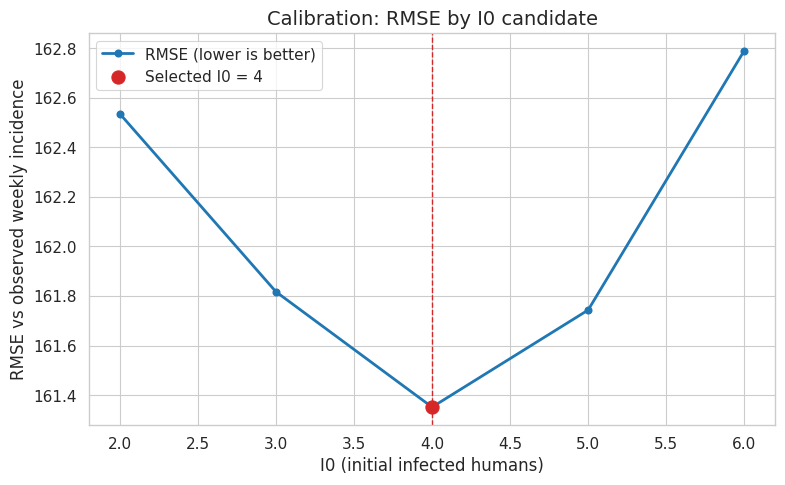

In [4]:
# Plot 1: RMSE vs I0 (selection summary)
fig, ax = plt.subplots()

# Line with markers for RMSE
ax.plot(selection_df['I0'], selection_df['J'], color='#1f77b4', marker='o', lw=2, label='RMSE (lower is better)')

# Highlight selected I0
sel_row = selection_df[selection_df['I0'] == hat_I0].iloc[0]
ax.scatter([hat_I0], [sel_row['J']], color='#d62728', s=90, zorder=5, label=f'Selected I0 = {hat_I0}')
ax.axvline(hat_I0, color='#d62728', ls='--', lw=1)

ax.set_title('Calibration: RMSE by I0 candidate')
ax.set_xlabel('I0 (initial infected humans)')
ax.set_ylabel('RMSE vs observed weekly incidence')
ax.legend()
plt.tight_layout()
plt.show()


In [5]:
# Aggregate weekly ensemble for selected I0 (first seed block only)
weeklies = load_weeklies_for_I0(hat_I0, base_seed=12345)
agg = aggregate_weeklies(weeklies)
agg['count'], agg['T']


(6, 53)

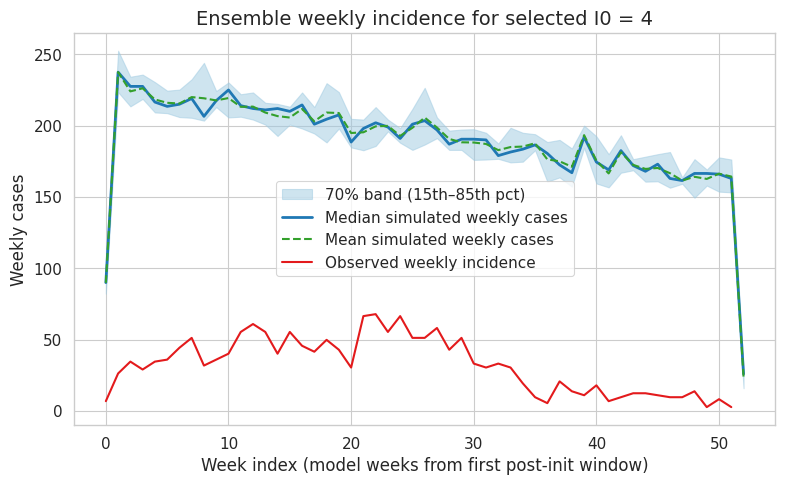

In [12]:
# Plot 2: Weekly ensemble for selected I0 with uncertainty band
fig, ax = plt.subplots()

if agg.get('T', 0) > 0:
    weeks = np.arange(agg['T'])
    ax.fill_between(weeks, agg['p15'], agg['p85'], color='#9ecae1', alpha=0.5, label='70% band (15th–85th pct)')
    ax.plot(weeks, agg['median'], color='#1f78b4', lw=2.0, label='Median simulated weekly cases')
    ax.plot(weeks, agg['mean'], color='#33a02c', lw=1.5, ls='--', label='Mean simulated weekly cases')
else:
    ax.text(0.5, 0.5, 'No weekly data found for first seed block.', transform=ax.transAxes, ha='center')

# Optionally overlay observed if provided
if OBSERVED_CSV is not None and Path(OBSERVED_CSV).exists():
    df_obs = pd.read_csv(OBSERVED_CSV).sort_values('week_continuous')
    y_obs = df_obs['incidence_rate_adjusted'].to_numpy()
    # Align: model weeks start at 0 in this plot; observation uses continuous weeks; we show post-week-26 window if desired.
    # Here, we overlay from its own index to avoid implying exact alignment.
    ax.plot(np.arange(len(y_obs)), y_obs, color='#e31a1c', lw=1.5, label='Observed weekly incidence')

ax.set_title(f'Ensemble weekly incidence for selected I0 = {hat_I0}')
ax.set_xlabel('Week index (model weeks from first post-init window)')
ax.set_ylabel('Weekly cases')
ax.legend()
plt.tight_layout()
plt.show()


Pearson r (no lag): 0.747
Spearman rho (no lag): 0.710
Best lag: 8 weeks | r=0.792
Directional agreement: 47.06%
RMSE (z-scored, smoothed): 0.711


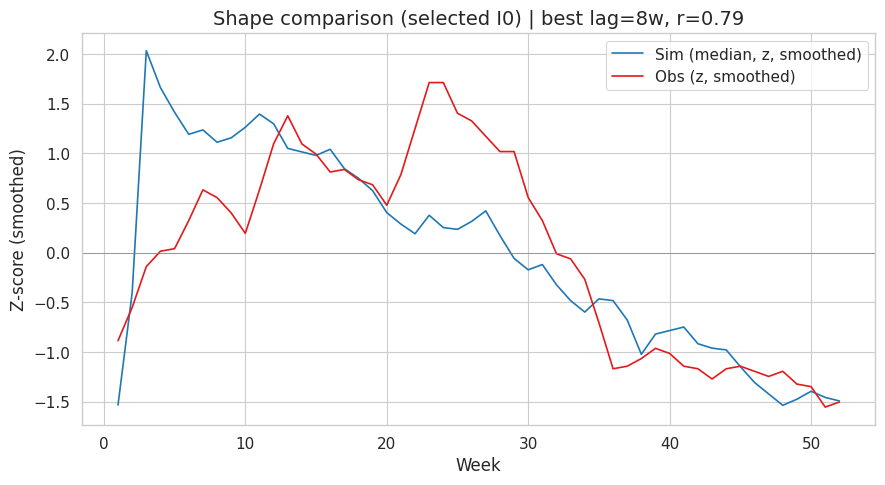

In [11]:
# Trend similarity between simulated and observed weekly incidence (selected I0)
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Build simulated series from the aggregated ensemble
if agg.get('T', 0) == 0:
    print("No simulated weekly series available (agg['T'] == 0).")
else:
    sim_series = np.asarray(agg['median'], dtype=float)

    # Obtain observed series if not already present
    obs_series = None
    if 'y_obs' in globals():
        obs_series = np.asarray(y_obs, dtype=float)
    elif 'yobs' in globals():
        obs_series = np.asarray(yobs, dtype=float)
    elif OBSERVED_CSV is not None and Path(OBSERVED_CSV).exists():
        df_obs_ = pd.read_csv(OBSERVED_CSV).sort_values('week_continuous')
        obs_series = df_obs_['incidence_rate_adjusted'].to_numpy(dtype=float)

    if obs_series is None or len(obs_series) == 0:
        print("Observed series not available. Set OBSERVED_CSV or run previous cell that loads it.")
    else:
        # Trim to overlapping window
        T = int(min(len(sim_series), len(obs_series)))
        sim = sim_series[:T]
        obs = obs_series[:T]

        # Smooth (centered rolling mean)
        def smooth(x: np.ndarray, win: int = 3) -> np.ndarray:
            s = pd.Series(x).rolling(win, center=True, min_periods=1).mean().to_numpy()
            return s

        # Z-score normalize (shape comparison)
        def zscore(x: np.ndarray) -> np.ndarray:
            x = np.asarray(x, dtype=float)
            m = np.nanmean(x)
            s = np.nanstd(x)
            return (x - m) / (s + 1e-12)

        sim_s = zscore(smooth(sim, win=3))
        obs_s = zscore(smooth(obs, win=3))

        # Pearson and Spearman correlations (no lag)
        pearson_r = float(np.corrcoef(obs_s, sim_s)[0, 1])
        # Spearman without SciPy: Pearson correlation of ranks
        obs_ranks = pd.Series(obs_s).rank(method='average').to_numpy()
        sim_ranks = pd.Series(sim_s).rank(method='average').to_numpy()
        spearman_r = float(np.corrcoef(obs_ranks, sim_ranks)[0, 1])

        # Cross-correlation over lags (±8 weeks)
        def corr_at_lag(x: np.ndarray, y: np.ndarray, lag: int) -> float:
            if lag > 0:
                return float(np.corrcoef(x[lag:], y[:-lag])[0, 1]) if len(x) - lag > 1 else np.nan
            if lag < 0:
                L = -lag
                return float(np.corrcoef(x[:-L], y[L:])[0, 1]) if len(x) - L > 1 else np.nan
            return float(np.corrcoef(x, y)[0, 1])

        lags = np.arange(-8, 9)
        xcorr = np.array([corr_at_lag(obs_s, sim_s, L) for L in lags])
        best_idx = int(np.nanargmax(xcorr))
        best_lag = int(lags[best_idx])
        best_r = float(xcorr[best_idx])

        # Direction-of-change agreement
        obs_diff = np.sign(np.diff(obs_s))
        sim_diff = np.sign(np.diff(sim_s))
        directional_agreement = float(np.mean(obs_diff == sim_diff))

        # RMSE on z-scored, smoothed series
        rmse = float(np.sqrt(np.mean((obs_s - sim_s) ** 2)))

        print(f"Pearson r (no lag): {pearson_r:.3f}")
        print(f"Spearman rho (no lag): {spearman_r:.3f}")
        print(f"Best lag: {best_lag} weeks | r={best_r:.3f}")
        print(f"Directional agreement: {directional_agreement:.2%}")
        print(f"RMSE (z-scored, smoothed): {rmse:.3f}")

        # Overlay plot of normalized, smoothed series
        weeks = np.arange(1, T + 1)
        plt.figure(figsize=(9, 5))
        plt.plot(weeks, sim_s, label='Sim (median, z, smoothed)', color='#1f78b4')
        plt.plot(weeks, obs_s, label='Obs (z, smoothed)', color='#e31a1c')
        plt.axhline(0, color='gray', lw=0.5)
        plt.xlabel('Week')
        plt.ylabel('Z-score (smoothed)')
        plt.title(f'Shape comparison (selected I0) | best lag={best_lag}w, r={best_r:.2f}')
        plt.legend()
        plt.tight_layout()
        plt.show()


### Methodology for temporal trend comparison, validation context, and results

#### Data and preprocessing
- **Simulated series**: weekly median across replicates for the selected `I0` (`agg['median']`).
- **Observed series**: `incidence_rate_adjusted` from `view/incidence_rates_santa_marta.csv`, ordered by `week_continuous`.
- **Alignment**: both series are trimmed to a common window \(T = \min(\lvert\text{sim}\rvert,\lvert\text{obs}\rvert)\).
- **Smoothing (noise reduction)**: centered 3‑week rolling mean, `min_periods=1` at edges.

#### Standardization (z‑scores)
- Purpose: compare shapes independent of level and scale.
- For the smoothed series \(x_1,\dots,x_T\), with mean \(\mu=\frac{1}{T}\sum_{t=1}^{T}x_t\) and standard deviation \(\sigma=\sqrt{\frac{1}{T}\sum_{t=1}^{T}(x_t-\mu)^2}\),
  each point is standardized as:
- \( z_t = \dfrac{x_t - \mu}{\sigma + 10^{-12}} \).
- Interpretation: vertical units are the series’ own standard deviations; 0 is the series mean.

#### Statistics computed
- **Pearson correlation (no lag)**: linear similarity of the two z‑scored, smoothed series at the same weeks.
  - \( r = \text{corr}(z^{\text{obs}}, z^{\text{sim}}) \).
- **Spearman rank correlation (no lag)**: monotonic similarity; implemented as Pearson correlation of rank‑transformed values (no SciPy required).
- **Cross‑correlation with lag**: Pearson correlation for lags \(L \in [-8,8]\); positive \(L\) shifts observations forward by \(L\) weeks.
  - Report the lag with maximum \(r\) (best phase alignment).
- **Directional agreement**: fraction of weeks with the same sign of first differences:
  - \(\text{agree} = \frac{1}{T-1}\sum_{t=2}^{T}\mathbf{1}\{\text{sign}(\Delta z^{\text{obs}}_t)=\text{sign}(\Delta z^{\text{sim}}_t)\}\).
- **RMSE (shape error)** on z‑scored, smoothed series:
  - \(\text{RMSE} = \sqrt{\frac{1}{T}\sum_{t=1}^{T}(z^{\text{obs}}_t - z^{\text{sim}}_t)^2}\).

#### Why this contributes to validation
- Assesses **behavioral/temporal validity**: whether the model reproduces the epidemic’s macro‑shape and timing.
- Appropriate for validation when applied to **held‑out** periods/locations not used for calibration; otherwise, it is primarily a **fit diagnostic** (in‑sample).
- Complements magnitude‑based checks; z‑scoring removes scale, focusing on structure.

#### Results (this run)
- **Pearson (no lag)**: 0.747 → strong linear shape similarity.
- **Spearman (no lag)**: 0.710 → strong monotonic agreement in rise/decline ordering.
- **Best lag**: 8 weeks with \(r=0.792\) → curves align substantially better when shifted by ~2 months, indicating a systematic phase shift.
- **Directional agreement**: 47.06% → short‑term ups/downs match only about chance; weekly volatility not captured.
- **RMSE (z‑scored)**: 0.711 → moderate average deviation after standardization.

#### Implications
- The model captures the overall epidemic wave shape but peaks too early/late by ~8 weeks.
- Short‑term dynamics differ; consider refining seasonality/contact forcing or stochastic noise.
- For validation claims, repeat these metrics on held‑out weeks or other neighborhoods, and add raw‑unit error metrics (RMSE/MAE, peak timing/size errors) and uncertainty calibration (e.g., observed coverage within predictive bands, CRPS/log score).

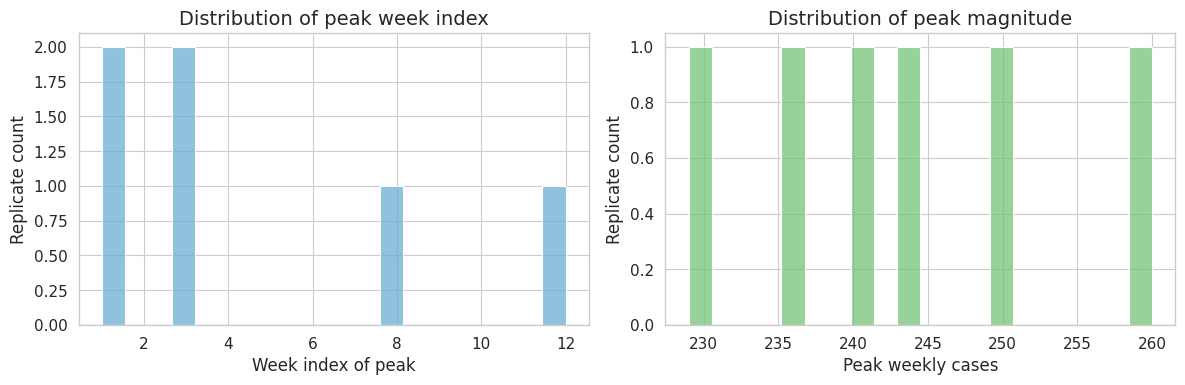

In [7]:
# Plot 3: Peak timing and magnitude distributions (selected I0)

# Compute per-replicate peaks from the weekly series
peaks = []
for w in weeklies:
    if len(w) == 0:
        continue
    idx = int(np.argmax(w))
    val = float(w[idx])
    peaks.append({"peak_week_index": idx, "peak_value": val})

peaks_df = pd.DataFrame(peaks)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(peaks_df['peak_week_index'], bins=20, kde=False, color='#6baed6', ax=axes[0])
axes[0].set_title('Distribution of peak week index')
axes[0].set_xlabel('Week index of peak')
axes[0].set_ylabel('Replicate count')

sns.histplot(peaks_df['peak_value'], bins=20, kde=False, color='#74c476', ax=axes[1])
axes[1].set_title('Distribution of peak magnitude')
axes[1].set_xlabel('Peak weekly cases')
axes[1].set_ylabel('Replicate count')

plt.tight_layout()
plt.show()


In [8]:
# Load second-seed-block (final ensemble) weeklies for selected I0
# The final mode uses base_seed + 10_000; default base_seed=12345 -> 22345
FINAL_BASE = 12345 + 10_000


def list_second_seed_block_files(I0: int, final_base: int = FINAL_BASE, r_max: int | None = None) -> list[Path]:
    cdir = candidate_dir(I0)
    if not cdir.exists():
        return []
    files = []
    for p in sorted(cdir.glob('seed_*.csv')):
        seed = seed_from_filename(p.name)
        if seed is None:
            continue
        r = seed - final_base
        if 0 <= r < 10000 and (r_max is None or r < r_max):
            files.append(p)
    return files


def load_weeklies_for_I0_second_block(I0: int, final_base: int = FINAL_BASE, r_max: int | None = None) -> list[np.ndarray]:
    weeklies = []
    for fp in list_second_seed_block_files(I0, final_base=final_base, r_max=r_max):
        df = read_results_csv(fp)
        weeklies.append(daily_to_weekly(df, start_tick=1))
    return weeklies

weeklies_final = load_weeklies_for_I0_second_block(hat_I0, final_base=FINAL_BASE)
agg_final = aggregate_weeklies(weeklies_final)
agg_final.get('count', 0), agg_final.get('T', 0)


(10, 53)

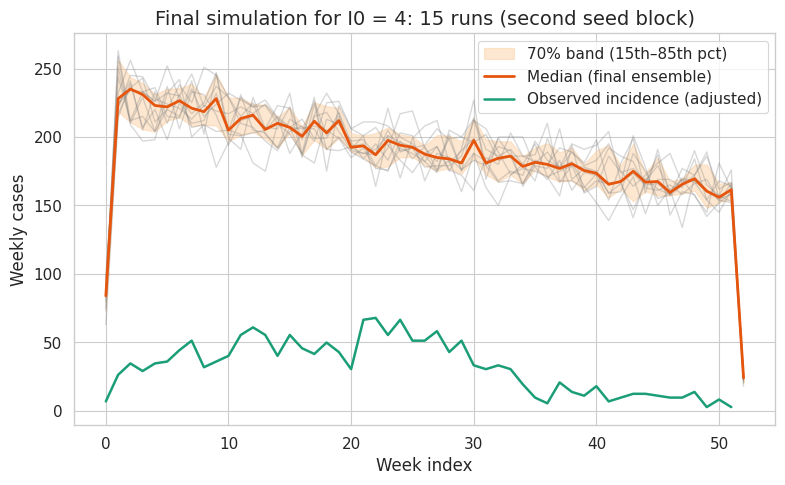

In [9]:
# Plot 5: Final ensemble (second seed block) – 15-run spaghetti + band
fig, ax = plt.subplots()

# Spaghetti
if len(weeklies_final) > 0:
    max_len = max(len(w) for w in weeklies_final)
    for w in weeklies_final:
        ax.plot(np.arange(len(w)), w, color='gray', alpha=0.3, linewidth=1)

if agg_final.get('T', 0) > 0:
    weeks_f = np.arange(agg_final['T'])
    ax.fill_between(weeks_f, agg_final['p15'], agg_final['p85'], color='#fdd0a2', alpha=0.5, label='70% band (15th–85th pct)')
    ax.plot(weeks_f, agg_final['median'], color='#e6550d', lw=2.0, label='Median (final ensemble)')

# Overlay observed incidence (use new calibration CSV if available)
obs_path = Path('view/incidence_rates_santa_marta.csv')
if obs_path.exists():
    df_obs = pd.read_csv(obs_path).sort_values('week_continuous')
    yobs = df_obs['incidence_rate_adjusted'].to_numpy()
    T = min(len(yobs), agg_final.get('T', len(yobs)))
    ax.plot(np.arange(T), yobs[:T], color='#1b9e77', lw=1.8, label='Observed incidence (adjusted)')
elif OBSERVED_CSV is not None and Path(OBSERVED_CSV).exists():
    df_obs = pd.read_csv(OBSERVED_CSV).sort_values('week_continuous')
    # Use post-26 window to match calibration window
    df_obs = df_obs[df_obs['week_continuous'] > 26]
    yobs = df_obs['incidence_rate_adjusted'].to_numpy()
    T = min(len(yobs), agg_final.get('T', len(yobs)))
    ax.plot(np.arange(T), yobs[:T], color='#1b9e77', lw=1.8, label='Observed incidence')

ax.set_title(f'Final simulation for I0 = {hat_I0}: 15 runs (second seed block)')
ax.set_xlabel('Week index')
ax.set_ylabel('Weekly cases')
ax.legend(loc='upper right', frameon=True)
plt.tight_layout()
plt.show()


Pearson r (no lag): 0.664
Spearman rho (no lag): 0.698
Best lag: 8 weeks | r=0.787
Directional agreement: 56.86%
RMSE (z-scored, smoothed): 0.820


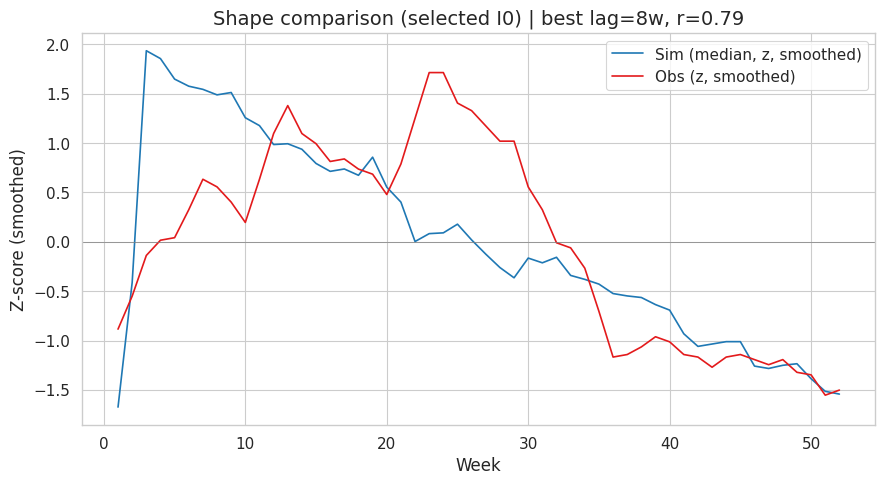

In [13]:
# Trend similarity between simulated and observed weekly incidence (selected I0)
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Build simulated series from the aggregated ensemble
if agg_final.get('T', 0) == 0:
    print("No simulated weekly series available (agg_final['T'] == 0).")
else:
    sim_series = np.asarray(agg_final['median'], dtype=float)

    # Obtain observed series if not already present
    obs_series = None
    if 'y_obs' in globals():
        obs_series = np.asarray(y_obs, dtype=float)
    elif 'yobs' in globals():
        obs_series = np.asarray(yobs, dtype=float)
    elif OBSERVED_CSV is not None and Path(OBSERVED_CSV).exists():
        df_obs_ = pd.read_csv(OBSERVED_CSV).sort_values('week_continuous')
        obs_series = df_obs_['incidence_rate_adjusted'].to_numpy(dtype=float)

    if obs_series is None or len(obs_series) == 0:
        print("Observed series not available. Set OBSERVED_CSV or run previous cell that loads it.")
    else:
        # Trim to overlapping window
        T = int(min(len(sim_series), len(obs_series)))
        sim = sim_series[:T]
        obs = obs_series[:T]

        # Smooth (centered rolling mean)
        def smooth(x: np.ndarray, win: int = 3) -> np.ndarray:
            s = pd.Series(x).rolling(win, center=True, min_periods=1).mean().to_numpy()
            return s

        # Z-score normalize (shape comparison)
        def zscore(x: np.ndarray) -> np.ndarray:
            x = np.asarray(x, dtype=float)
            m = np.nanmean(x)
            s = np.nanstd(x)
            return (x - m) / (s + 1e-12)

        sim_s = zscore(smooth(sim, win=3))
        obs_s = zscore(smooth(obs, win=3))

        # Pearson and Spearman correlations (no lag)
        pearson_r = float(np.corrcoef(obs_s, sim_s)[0, 1])
        # Spearman without SciPy: Pearson correlation of ranks
        obs_ranks = pd.Series(obs_s).rank(method='average').to_numpy()
        sim_ranks = pd.Series(sim_s).rank(method='average').to_numpy()
        spearman_r = float(np.corrcoef(obs_ranks, sim_ranks)[0, 1])

        # Cross-correlation over lags (±8 weeks)
        def corr_at_lag(x: np.ndarray, y: np.ndarray, lag: int) -> float:
            if lag > 0:
                return float(np.corrcoef(x[lag:], y[:-lag])[0, 1]) if len(x) - lag > 1 else np.nan
            if lag < 0:
                L = -lag
                return float(np.corrcoef(x[:-L], y[L:])[0, 1]) if len(x) - L > 1 else np.nan
            return float(np.corrcoef(x, y)[0, 1])

        lags = np.arange(-8, 9)
        xcorr = np.array([corr_at_lag(obs_s, sim_s, L) for L in lags])
        best_idx = int(np.nanargmax(xcorr))
        best_lag = int(lags[best_idx])
        best_r = float(xcorr[best_idx])

        # Direction-of-change agreement
        obs_diff = np.sign(np.diff(obs_s))
        sim_diff = np.sign(np.diff(sim_s))
        directional_agreement = float(np.mean(obs_diff == sim_diff))

        # RMSE on z-scored, smoothed series
        rmse = float(np.sqrt(np.mean((obs_s - sim_s) ** 2)))

        print(f"Pearson r (no lag): {pearson_r:.3f}")
        print(f"Spearman rho (no lag): {spearman_r:.3f}")
        print(f"Best lag: {best_lag} weeks | r={best_r:.3f}")
        print(f"Directional agreement: {directional_agreement:.2%}")
        print(f"RMSE (z-scored, smoothed): {rmse:.3f}")

        # Overlay plot of normalized, smoothed series
        weeks = np.arange(1, T + 1)
        plt.figure(figsize=(9, 5))
        plt.plot(weeks, sim_s, label='Sim (median, z, smoothed)', color='#1f78b4')
        plt.plot(weeks, obs_s, label='Obs (z, smoothed)', color='#e31a1c')
        plt.axhline(0, color='gray', lw=0.5)
        plt.xlabel('Week')
        plt.ylabel('Z-score (smoothed)')
        plt.title(f'Shape comparison (selected I0) | best lag={best_lag}w, r={best_r:.2f}')
        plt.legend()
        plt.tight_layout()
        plt.show()


## How to read the figures

- **RMSE vs I0 (Plot 1)**: Each point is a candidate I0 and its root-mean-square error (RMSE) against observed weekly incidence (lower is better). The dashed vertical line and red marker highlight the selected value `I0 = hat_I0`. Differences of a few RMSE units may be negligible depending on noise; interpret relative gaps.

- **Weekly ensemble (Plot 2)**: For the selected I0, each replicate is aggregated to weekly cases. The shaded band shows the middle 70% (15th–85th percentiles), the solid blue line is the median, and the dashed green line is the mean across replicates. If an observed time series is provided, it is drawn in red for visual comparison. Align the time base qualitatively; week index 0 in the model corresponds to the first modeled week after initialization.

- **Peak timing and magnitude (Plot 3)**: Histograms show the distribution across replicates of the week index of the peak and its magnitude (weekly cases at the peak). Concentrated distributions indicate consistent epidemic dynamics; broader distributions suggest higher stochastic variability for the selected I0.

- **Replicate counts (Plot 4)**: Bars indicate how many replicate CSVs were found per candidate I0 for the first seed block (base seed 12345). This helps verify balance across candidates when comparing RMSE. The selected I0 is marked with a dashed vertical line.



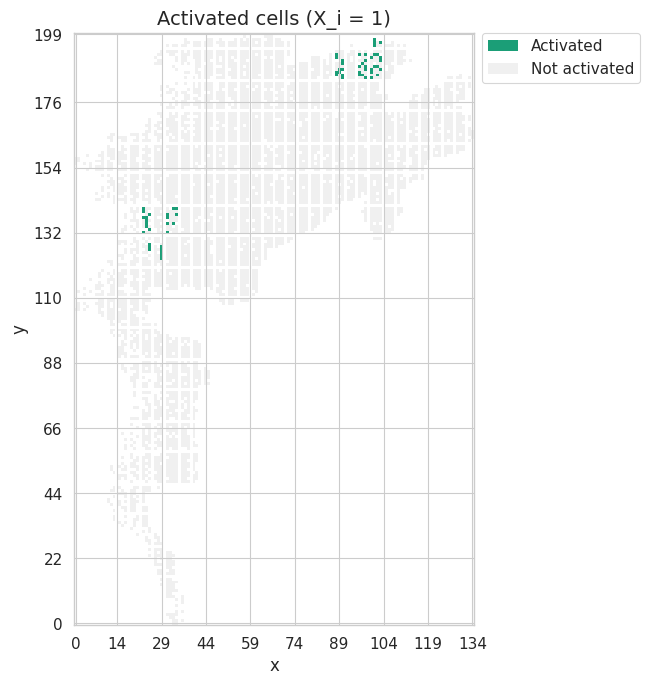

,neighborhood_id,activation_rate
0,0,0.000000
1,1,0.324324
2,2,0.263158
3,3,0.407407
4,4,0.423077


In [35]:
# Plot activated cells map from hi_activation_map.csv
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Data paths
hi_map_path = Path('hi_activation_map.csv')

if not hi_map_path.exists():
    raise FileNotFoundError(f"Missing file: {hi_map_path}")

hi_df = pd.read_csv(hi_map_path)
# Expect columns: x, y, neighborhood_id, HI_bar, X_i, omega_i
required_cols = {'x', 'y', 'neighborhood_id', 'HI_bar', 'X_i', 'omega_i'}
missing = required_cols.difference(hi_df.columns)
if missing:
    raise ValueError(f"hi_activation_map.csv missing columns: {sorted(missing)}")

# Define activation: X_i == 1 (activated) else 0
hi_df['activated'] = (hi_df['X_i'] == 1).astype(int)

# Determine grid extents for plotting
xmin, xmax = hi_df['x'].min(), hi_df['x'].max()
ymin, ymax = hi_df['y'].min(), hi_df['y'].max()
width = int(xmax - xmin + 1)
height = int(ymax - ymin + 1)

# Build a 2D array with NaN for missing cells and 1/0 for activated/non-activated
grid = np.full((height, width), np.nan, dtype=float)
for _, r in hi_df.iterrows():
    gx = int(r['x'] - xmin)
    gy = int(r['y'] - ymin)
    grid[gy, gx] = r['activated']

# Plot
fig, ax = plt.subplots(figsize=(8, 7))
cmap = mpl.colors.ListedColormap(['#f0f0f0', '#1b9e77'])  # 0=light gray, 1=green
im = ax.imshow(grid, origin='lower', interpolation='none', cmap=cmap, vmin=0, vmax=1)
ax.set_title('Activated cells (X_i = 1)')
ax.set_xlabel('x')
ax.set_ylabel('y')
# Ticks as original coordinates sparsely
xticks = np.linspace(0, width-1, num=min(10, width), dtype=int)
yticks = np.linspace(0, height-1, num=min(10, height), dtype=int)
ax.set_xticks(xticks)
ax.set_xticklabels((xticks + xmin).astype(int))
ax.set_yticks(yticks)
ax.set_yticklabels((yticks + ymin).astype(int))

# Legend proxies
from matplotlib.patches import Patch
legend_handles = [
    Patch(facecolor='#1b9e77', edgecolor='none', label='Activated'),
    Patch(facecolor='#f0f0f0', edgecolor='none', label='Not activated')
]
# move legend outside the axes on the right and add space for it
plt.subplots_adjust(right=0.8)
ax.legend(handles=legend_handles, loc='upper left', bbox_to_anchor=(1.02, 1), borderaxespad=0.0, frameon=True)
plt.tight_layout()
plt.show()

# Also report activation proportion by neighborhood_id
activation_by_neigh = (hi_df.groupby('neighborhood_id')['activated']
                           .mean()
                           .rename('activation_rate')
                           .reset_index())
activation_by_neigh.head()


In [33]:
# Compare activation proportions vs hi_by_neighborhood_2023.csv
from pathlib import Path
import pandas as pd
import numpy as np

# Inputs
hi_map_path = Path('hi_activation_map.csv')
hi_target_path = Path('view/hi_by_neighborhood_2023.csv')

if not hi_map_path.exists():
    raise FileNotFoundError(f"Missing file: {hi_map_path}")
if not hi_target_path.exists():
    raise FileNotFoundError(f"Missing file: {hi_target_path}")

hi_df = pd.read_csv(hi_map_path)
required_cols = {'x', 'y', 'neighborhood_id', 'HI_bar', 'X_i', 'omega_i'}
missing = required_cols.difference(hi_df.columns)
if missing:
    raise ValueError(f"hi_activation_map.csv missing columns: {sorted(missing)}")

# Activation per cell
hi_df['activated'] = (hi_df['X_i'] == 1).astype(int)

# Compute realized activation proportion per neighborhood_id
realized = (hi_df.groupby('neighborhood_id')['activated']
                .agg(realized_activation_rate='mean', n_cells='size')
                .reset_index())

# Load target HI proportions per neighborhood (mean)
target = pd.read_csv(hi_target_path)
# Expect columns: neighborhood_id, neighborhood_name, hi_mean
req_tgt = {'neighborhood_id', 'neighborhood_name', 'hi_mean'}
missing_tgt = req_tgt.difference(target.columns)
if missing_tgt:
    raise ValueError(f"hi_by_neighborhood_2023.csv missing columns: {sorted(missing_tgt)}")

# Merge
comp = target.merge(realized, on='neighborhood_id', how='left')
comp['realized_activation_rate'] = comp['realized_activation_rate'].fillna(0.0)
comp['diff'] = comp['realized_activation_rate'] - comp['hi_mean']
comp = comp.sort_values('neighborhood_id').reset_index(drop=True)

# Display summary table
cols = ['neighborhood_id', 'neighborhood_name', 'n_cells', 'hi_mean', 'realized_activation_rate', 'diff']
comp[cols]



,neighborhood_id,neighborhood_name,n_cells,hi_mean,realized_activation_rate,diff
0,1,OASIS,37,0.249429,0.324324,0.074896
1,2,LA QUININA,19,0.217489,0.263158,0.045669
2,3,ONDAS DEL CARIBE,27,0.286750,0.407407,0.120657
3,4,PANTANO,26,0.256500,0.423077,0.166577
4,5,8 DE DICIEMBRE,7,0.325333,0.571429,0.246095
5,6,LA COQUERA,9,0.274750,0.333333,0.058583
6,7,SAN JACINTO,21,0.258833,0.476190,0.217357
7,8,NUEVA BETHEL,31,0.271000,0.258065,-0.012935


In [ ]:
python3 calibration_I0.py --mode final \
  --observed view/incidence_rates_santa_marta.csv \
  --props props/model.props --config props/config.props \
  --workdir . --make-target all \
  --replicates-final 10 --r-start 0 --r-end 10 \
  --outdir calib_I0_runs_v2